# Differentiable Monte Carlo — The Real Deal

**Goal:** make the MC PLE pipeline differentiable so we can recover parameters by
gradient descent instead of grid search.

This notebook makes the **line width `gamma`** differentiable end-to-end:
`loss = mmd2_biased(log10(sim), log10(real)); loss.backward()` populates
`gamma.grad`. Two pieces (per the journal): reparameterized sampling so `gamma`
flows into the photons, and **implicit differentiation** through the per-run fit
(no unrolling of the optimizer).

`nbar` (mean photon count) is held fixed this round — its discrete count needs a
finite-difference surrogate, which is the next step.

---

## Step 1: Imports & Setup

In [3]:
import math
from dataclasses import dataclass

import numpy as np
import torch
import torch.func as tfunc
import matplotlib.pyplot as plt

# float64: the implicit-diff Hessian solve wants the extra precision; cost is tiny
# at these sizes.
torch.set_default_dtype(torch.float64)

# Detuning window the spectrometer records, in MHz (from paper).
FREQ_MIN = -75.0
FREQ_MAX = 75.0
UNIFORM_DENSITY = 1.0 / (FREQ_MAX - FREQ_MIN)

## Step 2: Parameters & Reparameterized Sampling

Each run draws a photon count `N`, then `N` signal detunings from a Lorentzian
(Cauchy) line of HWHM `gamma`, plus a uniform background. Two changes from the
original forward-only code make this differentiable and correct:

1. **Reparameterization** — the randomness is fixed per run as quantiles `u` (and
   background `b`, count `N`); the signal detunings `gamma * tan(pi*(u-0.5))` are
   then a *differentiable function of gamma*.
2. **Truncation, not clipping** — photons outside `[FREQ_MIN, FREQ_MAX]` are *not
   detected* (dropped), rather than piled onto the window edges. Clipping-to-edge
   created spurious spikes that biased the fit and broke monotonicity of FWHM in
   `gamma`; truncation (with the truncation-aware likelihood in Step 3) is both
   physically correct and recovers `gamma` cleanly.

In [2]:
@dataclass
class MCParams:
    """Parameters of the Monte-Carlo PLE forward model (one emitter line).

    A "run" is one simulated PLE measurement: we collect a set of photons whose
    detunings (frequency offsets from line center, in MHz) we later fit to read
    off a line width (FWHM). Photons come from two sources:

      * signal     - drawn from a Lorentzian (Cauchy) line of HWHM `gamma`
      * background - stray counts spread uniformly across the detection window

    Attributes:
        gamma:   Lorentzian HWHM (MHz). THE quantity we reconstruct; the whole
                 pipeline is made differentiable w.r.t. this. Line FWHM = 2*gamma.
        nbar:    Mean number of signal photons per run. Held fixed this round (its
                 photon count is discrete -> needs a finite-difference surrogate,
                 which comes later).
        sigma:   Std of the per-run photon-count noise, N(nbar, sigma). Fixed (paper).
        lambda_: Mean number of uniform background counts per run. Fixed (paper).
    """
    gamma: float
    nbar: float
    sigma: float = 6.0
    lambda_: float = 2.0


def draw_fixed_noise(params, rng):
    """Draw and FREEZE all of one run's parameter-free randomness up front.

    This is the setup half of the reparameterization trick. Sampling photon
    positions directly would entangle the randomness with `gamma` (e.g.
    `np.random.standard_cauchy() * gamma`), leaving no clean derivative. Instead we
    draw only the *raw* randomness here and apply `gamma` later, separately, in
    `signal_detunings`. That keeps the photon positions a smooth, differentiable
    function of `gamma`, which is what the whole differentiable pipeline relies on.

    Three pieces are returned, drawn once and held fixed for the run:
        u : (N,) uniform(0,1) "quantiles" - one raw seed per signal photon. NOT
            positions yet; `signal_detunings(gamma, u)` maps them to Lorentzian
            detunings. Frozen here so the SAME draw can be replayed at any `gamma`
            (essential for the gradient / Hessian, which evaluate photons(gamma) at
            perturbed gamma using these same u's).
        b : (M,) background detunings (MHz), already in final form - drawn
            uniformly over the detection window. The background does not depend on
            `gamma`, so there is nothing to defer: we store its positions directly.
        N : int - number of signal photons this run, drawn N(nbar, sigma), then
            rounded and floored at 0. Discrete (hence non-differentiable), which is
            exactly why `nbar` is held fixed this round.

    Note that the actual number of DETECTED signal photons is <= N: photons whose
    detunings fall outside the window are dropped later by `detect_mask`. The
    background count is itself random, Poisson(lambda_).

    Args:
        params: MCParams (uses nbar, sigma, lambda_).
        rng:    numpy Generator - the single source of this run's randomness;
                pass a seeded generator for reproducible runs.

    Returns:
        (u, b, N): u of shape (N,) and b of shape (M,) are torch tensors
        (float64 by the global default dtype); N is a Python int.
    """
    n = int(max(round(params.nbar + params.sigma * rng.standard_normal()), 0))
    u = torch.tensor(rng.uniform(0.0, 1.0, size=n))
    b = torch.tensor(rng.uniform(FREQ_MIN, FREQ_MAX, size=int(rng.poisson(params.lambda_))))
    return u, b, n


def signal_detunings(gamma, u):
    """Map frozen quantiles `u` to Lorentzian signal detunings (the reparam trick).

    The "apply gamma" half of the reparameterization. Signal photons are
    Cauchy(0, gamma) distributed; we generate them by inverse-transform sampling
    (the probability integral transform). The Cauchy density and CDF are

        p(x) = (1/pi) * gamma / (x^2 + gamma^2)
        F(x) = 1/2 + (1/pi) * arctan(x / gamma)

    Inverting u = F(x) gives the quantile function used here:

        detuning = F^-1(u) = gamma * tan(pi * (u - 0.5))

    So a uniform u in (0,1) is pushed through F^-1 to yield a Cauchy(0, gamma)
    sample. Quick sanity points: u=0.5 -> 0 (line center); u=0.25/0.75 ->
    -gamma/+gamma (the quartiles sit at +/-gamma, consistent with gamma = HWHM);
    u -> 0 or 1 -> +/- infinity (the heavy Cauchy tails).

    Why this matters for differentiability: `u` is frozen, so `gamma` enters only
    as a smooth multiplier and the per-photon derivative is exact,

        d(detuning)/d(gamma) = tan(pi * (u - 0.5)),

    with no randomness between `gamma` and the output. Holding `u` fixed, every
    photon position is a differentiable function of `gamma`.

    Args:
        gamma: scalar tensor - Lorentzian HWHM (MHz); the parameter we differentiate.
        u:     (N,) tensor - frozen uniform(0,1) quantiles from draw_fixed_noise.

    Returns:
        (N,) tensor of signal detunings (MHz), UNtruncated - window truncation is
        applied separately by `detect_mask` / `build_photons_forward`.
    """
    return gamma * torch.tan(math.pi * (u - 0.5))


def detect_mask(detunings):
    """Boolean mask: which detunings fall inside the spectrometer's window.

    The detector only records photons with detuning strictly inside
    (FREQ_MIN, FREQ_MAX). Because the Cauchy line has heavy ~1/x^2 tails, a real
    fraction of signal photons land outside the window (e.g. ~17% at gamma=30) and
    are simply NOT detected. We model that by DROPPING them (truncation), which is
    what the instrument physically does.

    This is deliberately NOT clip-to-edge: the original code piled out-of-window
    mass onto +/-FREQ_MAX, creating artificial spikes that biased the fit and made
    the recovered FWHM non-monotonic in `gamma` (so `gamma` was not recoverable).
    Truncation, paired with the truncation-aware likelihood in Step 3, fixes that.

    The strict inequalities exclude exact boundary hits (probability zero for a
    continuous draw). The mask itself is discrete / non-differentiable - the
    pipeline copes by freezing photon membership; see `build_photons_forward`
    vs `build_photons_fixed`.

    Args:
        detunings: (K,) tensor of detunings (MHz).

    Returns:
        (K,) boolean tensor - True where FREQ_MIN < detuning < FREQ_MAX.
    """
    return (detunings > FREQ_MIN) & (detunings < FREQ_MAX)


def build_photons_forward(gamma, u, b):
    """Forward pass: produce the photons the detector actually records this run.

    Runs the full physical pipeline at the current `gamma`:
        1. map frozen quantiles to signal detunings (`signal_detunings`),
        2. keep only those inside the detection window (`detect_mask`),
        3. append the (gamma-independent) background `b`.

    It ALSO returns `u_kept`, the quantiles of the signal photons that survived
    detection. Recording who survived is what lets the backward / Hessian pass
    replay the SAME photon set at other `gamma` values without re-running the
    (discrete, non-differentiable) detection step. In other words it FREEZES the
    photon membership: differentiation then varies only the photons' POSITIONS
    with `gamma`, never which photons exist - so the per-run gradient is well
    defined (no discontinuous jumps as a photon crosses the window edge). The
    counterpart that consumes `u_kept` is `build_photons_fixed`.

    Args:
        gamma: scalar tensor - Lorentzian HWHM (MHz).
        u:     (N,) tensor - frozen signal quantiles from draw_fixed_noise.
        b:     (M,) tensor - frozen background detunings.

    Returns:
        (photons, u_kept):
            photons: (K + M,) tensor - detected signal (K <= N kept) + background,
                     i.e. the data we hand to the fit.
            u_kept:  (K,) tensor - quantiles of the surviving signal photons,
                     saved so the gradient pass keeps the SAME membership.
    """
    s = signal_detunings(gamma, u)
    m = detect_mask(s)
    return torch.cat([s[m], b]), u[m]


def build_photons_fixed(gamma, u_kept, b):
    """Backward/Hessian pass: rebuild the photons with membership held FIXED.

    Identical to `build_photons_forward` except there is NO detection step: it
    trusts the already-chosen survivors `u_kept` and only recomputes their
    positions at this `gamma`, then appends the background. This is the version
    differentiated by the implicit-function-theorem machinery (Step 4): we hold
    "which photons exist" constant (decided once, in the forward pass) and let
    only their positions move smoothly with `gamma`. That makes the inner NLL a
    smooth function of `gamma` through the data, so dFWHM/dgamma is well defined
    and the cross-Hessian block H_{theta,gamma} is meaningful.

    Args:
        gamma:  scalar tensor - Lorentzian HWHM (MHz); the differentiation variable.
        u_kept: (K,) tensor - quantiles of the surviving signal photons (from
                build_photons_forward).
        b:      (M,) tensor - frozen background detunings.

    Returns:
        (K + M,) tensor of photons (signal at this gamma + background), with the
        same membership as the forward pass.
    """
    return torch.cat([signal_detunings(gamma, u_kept), b])

## Step 3: Fitting — Truncation-aware Lorentzian + Background (MLE)

The signal is sampled from a pure Lorentzian, so the matched estimator is a
Lorentzian MLE (not the old pseudo-Voigt). We fit the true generative mixture —
a Lorentzian plus uniform background — and **renormalize the Lorentzian over the
window** so the likelihood is correct for truncated data. This gives an unbiased
`gamma` and a well-conditioned 3-parameter Hessian for the implicit diff.

Params (unconstrained for the optimizer): `theta = (center, log_gamma, logit_w)`,
with `gamma_fit = exp(log_gamma)`, signal fraction `w = sigmoid(logit_w)`.
Line width: `FWHM = 2 * gamma_fit`.

In [3]:
def _lorentz_cdf(x, center, gamma):
    return 0.5 + torch.atan((x - center) / gamma) / math.pi


def lorentzian_uniform_log_pdf(freqs, center, log_gamma, logit_w):
    """Log pdf of  w * Lorentz(center,gamma)|window-truncated + (1-w) * Uniform.

    The Lorentzian is divided by its mass Z inside [FREQ_MIN, FREQ_MAX], so the
    likelihood is correct for window-truncated detunings.
    """
    gamma = torch.exp(log_gamma)
    w = torch.sigmoid(logit_w)
    lorentz = (gamma / math.pi) / ((freqs - center) ** 2 + gamma ** 2)
    hi = torch.as_tensor(FREQ_MAX, dtype=freqs.dtype)
    lo = torch.as_tensor(FREQ_MIN, dtype=freqs.dtype)
    Z = _lorentz_cdf(hi, center, gamma) - _lorentz_cdf(lo, center, gamma)
    pdf = w * lorentz / Z + (1.0 - w) * UNIFORM_DENSITY
    return torch.log(pdf + 1e-30)


def nll(theta, photons):
    """Mean negative log-likelihood; theta = (center, log_gamma, logit_w)."""
    return -lorentzian_uniform_log_pdf(photons, theta[0], theta[1], theta[2]).mean()


def fit_lorentzian(photons, n_iters=100):
    """MLE fit via L-BFGS. Returns theta* (detached, shape (3,)) or None on failure.

    The fit is run on detached data purely to locate the optimum theta*; the
    gradient w.r.t. gamma comes from implicit differentiation (Step 4), not from
    backpropagating through these iterations.
    """
    if len(photons) < 3:
        return None
    data = photons.detach()
    theta = torch.tensor([float(data.median()), math.log(15.0), 0.0],
                         requires_grad=True)
    opt = torch.optim.LBFGS([theta], max_iter=n_iters, line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        loss = nll(theta, data)
        loss.backward()
        return loss

    try:
        opt.step(closure)
    except RuntimeError:
        return None
    return theta.detach() if torch.isfinite(theta).all() else None

## Step 4: Differentiating Through the Fit — Implicit Function Theorem

The fit is an `argmin`, so we can't (cheaply) backprop through the optimizer.
Instead we use the **implicit function theorem**. At the optimum `theta*(gamma)`
the inner gradient vanishes, `g(theta*, gamma) = dNLL/dtheta = 0`. Differentiating
that identity in `gamma`:

$$\frac{d\theta^*}{d\gamma} = -H_{\theta\theta}^{-1} H_{\theta\gamma}$$

where `H_tt = d^2 NLL/dtheta^2` (3x3) and `H_tg = d^2 NLL/dtheta dgamma` (3x1).
Here `gamma` enters the NLL **only through the data** `photons(gamma)`, which is
exactly why the cross block `H_tg` is non-zero. Then with `FWHM = 2*exp(log_gamma)`:

$$\frac{dFWHM}{d\gamma} = \Big[\tfrac{\partial FWHM}{\partial\theta}\Big]^{\top}\frac{d\theta^*}{d\gamma}.$$

We wrap one run as a `torch.autograd.Function`: forward runs the (detached) fit;
backward returns `dFWHM/dgamma` via the formula above, so it composes with the
outer MMD² graph automatically. Ill-conditioned runs (rare, bad fits) return a
zero gradient instead of a garbage one.

In [4]:
def hessian_blocks(theta_star, gamma, u_kept, b):
    """Return (H_tt 3x3, H_tg 3x1) of the inner NLL at (theta*, gamma).

    gamma enters only through photons(gamma) (fixed membership u_kept). Uses
    torch.func: H_tt = Jac_theta(grad_theta), H_tg = Jac_gamma(grad_theta).
    """
    def loss_of(theta, g):
        return nll(theta, build_photons_fixed(g, u_kept, b))

    grad_theta = tfunc.grad(loss_of, argnums=0)
    H_tt = tfunc.jacrev(grad_theta, argnums=0)(theta_star, gamma)
    H_tg = tfunc.jacrev(grad_theta, argnums=1)(theta_star, gamma).reshape(3, 1)
    return H_tt, H_tg


def dfwhm_dgamma(theta_star, gamma, u_kept, b):
    """Implicit-diff scalar dFWHM/dgamma at the optimum; None if ill-conditioned.

    Scale-aware Tikhonov regularization on H_tt; a non-PD or badly conditioned
    Hessian (or any LinAlg failure) returns None so the caller zeroes that run's
    contribution. The per-run gradient is clamped to a sane range.
    """
    H_tt, H_tg = hessian_blocks(theta_star, gamma, u_kept, b)
    if not (torch.isfinite(H_tt).all() and torch.isfinite(H_tg).all()):
        return None
    reg = 1e-6 * (H_tt.diagonal().abs().mean() + 1e-12)
    H = H_tt + reg * torch.eye(3, dtype=H_tt.dtype)
    try:
        eig = torch.linalg.eigvalsh(H)
        if eig.min() <= 0 or (eig.max() / eig.min()) > 1e10:
            return None
        dtheta_dg = -torch.linalg.solve(H, H_tg)
    except torch._C._LinAlgError:
        return None
    fwhm = 2.0 * torch.exp(theta_star[1])
    v = torch.tensor([0.0, fwhm.item(), 0.0], dtype=H_tt.dtype)  # dFWHM/dtheta
    return torch.clamp((v @ dtheta_dg).squeeze(), -10.0, 10.0)


class DifferentiableRun(torch.autograd.Function):
    """One MC run as an autograd node: gamma -> FWHM, with implicit-diff backward."""

    @staticmethod
    def forward(ctx, gamma, u, b):
        g = gamma.detach()
        photons, u_kept = build_photons_forward(g, u, b)
        theta_star = fit_lorentzian(photons)
        if theta_star is None:
            ctx.failed = True
            ctx.save_for_backward(g)
            return 2.0 * g  # differentiable proxy fallback (rare)
        ctx.failed = False
        ctx.save_for_backward(g, u_kept, b, theta_star)
        return 2.0 * torch.exp(theta_star[1])

    @staticmethod
    def backward(ctx, grad_out):
        if ctx.failed:
            return grad_out * 2.0, None, None  # d(2*gamma)/dgamma = 2
        g, u_kept, b, theta_star = ctx.saved_tensors
        grad = dfwhm_dgamma(theta_star, g, u_kept, b)
        if grad is None:
            return grad_out * 0.0, None, None
        return grad_out * grad, None, None


def run_fwhm(gamma, u, b):
    """Forward-only FWHM for a single run (used for finite-difference checks)."""
    photons, _ = build_photons_forward(gamma, u, b)
    theta_star = fit_lorentzian(photons)
    if theta_star is None:
        return 2.0 * float(gamma)
    return float(2.0 * torch.exp(theta_star[1]))

## Step 5: Simulation

`simulate_diff` runs many MC runs over a fixed noise set and stacks the FWHMs into
a tensor that is **differentiable in gamma**. `simulate_target` is the forward-only
version used to make the (detached) "real" data we fit against.

In [5]:
def draw_noise_set(n_runs, params, rng):
    """A list of per-run fixed noise tuples (u, b, N) for one simulation."""
    return [draw_fixed_noise(params, rng) for _ in range(n_runs)]


def simulate_diff(gamma, noise_set):
    """Differentiable-in-gamma FWHM samples over a fixed noise set."""
    out = []
    for u, b, n in noise_set:
        if n + len(b) < 3:
            out.append(2.0 * gamma)            # differentiable proxy
        else:
            out.append(DifferentiableRun.apply(gamma, u, b))
    return torch.stack(out)


def simulate_target(gamma, n_runs, params, rng):
    """Detached FWHM samples (forward only) — used to build the real-data target."""
    vals = [run_fwhm(torch.tensor(float(gamma)), u, b)
            for u, b, n in (draw_fixed_noise(params, rng) for _ in range(n_runs))]
    return torch.tensor(vals)

## Step 6: Loss Function — Biased MMD²

Both sides are sets of FWHM samples, so we compare them directly with the biased
MMD². We apply it in `log10` space (FWHM spans orders of magnitude → a single
kernel bandwidth is only meaningful on a log scale).

In [6]:
def gaussian_gram(a, b, bandwidth):
    """Gaussian kernel (Gram) matrix between two 1-D sample sets."""
    d2 = (a[:, None] - b[None, :]) ** 2
    return torch.exp(-d2 / (2.0 * bandwidth ** 2))


def median_bandwidth(x, y):
    """Median-heuristic bandwidth from pooled samples (detached = constant)."""
    z = torch.cat([x, y]).detach()
    d2 = (z[:, None] - z[None, :]) ** 2
    iu = torch.triu_indices(len(z), len(z), offset=1)
    return torch.median(d2[iu[0], iu[1]]).sqrt().clamp_min(1e-12)


def mmd2_biased(x, y, bandwidth=None):
    """Biased MMD^2 between sample sets x (sim) and y (real), Gaussian kernel."""
    if bandwidth is None:
        bandwidth = median_bandwidth(x, y)
    Kxx = gaussian_gram(x, x, bandwidth)
    Kyy = gaussian_gram(y, y, bandwidth)
    Kxy = gaussian_gram(x, y, bandwidth)
    return Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean()


def log_fwhm(x):
    """log10 of FWHM samples, floored to stay finite on degenerate fits."""
    return torch.log10(x.clamp_min(1e-3))


# Smoke test: matching params -> much lower MMD^2 than mismatched.
_p = MCParams(gamma=20.0, nbar=50.0)
_real = log_fwhm(simulate_target(20.0, 400, _p, np.random.default_rng(123)))
_ns = draw_noise_set(400, _p, np.random.default_rng(456))
with torch.no_grad():
    _good = mmd2_biased(log_fwhm(simulate_diff(torch.tensor(20.0), _ns)), _real)
    _bad = mmd2_biased(log_fwhm(simulate_diff(torch.tensor(10.0), _ns)), _real)
print(f"MMD^2 gamma=20 (match): {_good:.6f}")
print(f"MMD^2 gamma=10 (wrong): {_bad:.6f}  (should be larger)")

MMD^2 gamma=20 (match): 0.000276
MMD^2 gamma=10 (wrong): 0.526955  (should be larger)


## Step 7: Validation — Per-run Gradient vs Finite Difference

The key correctness gate: the implicit-diff gradient `dFWHM/dgamma` for a single
run must match a central finite difference of that run's FWHM (same fixed noise).
We expect a small median relative error; large errors only on runs whose true
gradient is ~0 (degenerate fits).

In [7]:
rng = np.random.default_rng(0)
params = MCParams(gamma=20.0, nbar=50.0)
gamma0 = 20.0
rels = []
for _ in range(60):
    u, b, n = draw_fixed_noise(params, rng)
    if n + len(b) < 5:
        continue
    g = torch.tensor(gamma0, requires_grad=True)
    fwhm = DifferentiableRun.apply(g, u, b)
    fwhm.backward()
    d_ift = g.grad.item()
    h = 1e-2
    d_fd = (run_fwhm(torch.tensor(gamma0 + h), u, b)
            - run_fwhm(torch.tensor(gamma0 - h), u, b)) / (2 * h)
    if abs(d_fd) > 1e-2:
        rels.append(abs(d_ift - d_fd) / abs(d_fd))
rels = np.array(rels)
print(f"per-run gradient check over {len(rels)} runs:")
print(f"  median rel err = {np.median(rels):.2%}")
print(f"  90th pct       = {np.quantile(rels, 0.9):.2%}")

per-run gradient check over 60 runs:
  median rel err = 0.12%
  90th pct       = 1.08%


## Step 8: End-to-end Recovery of gamma

The real test: generate "real" data at a known `gamma_true`, start from a wrong
`gamma`, and recover it by gradient descent on the log-space MMD² — gradients
flowing through the fit via implicit differentiation. `nbar` is held fixed.

For speed we use a few hundred runs per step during optimization (full 2000 is only
needed for final reporting). Fixed noise is resampled each step but held fixed
within a step (required for the implicit-diff gradient).

In [8]:
GAMMA_TRUE = 20.0
params = MCParams(gamma=GAMMA_TRUE, nbar=50.0)
N_RUNS = 200          # a few hundred runs is enough gradient signal; bump for final eval

real = log_fwhm(simulate_target(GAMMA_TRUE, 400, params, np.random.default_rng(2024)))

gamma = torch.tensor(10.0, requires_grad=True)   # deliberately wrong start
opt = torch.optim.Adam([gamma], lr=0.5)
rng_step = np.random.default_rng(0)

history = []
for step in range(70):
    noise = draw_noise_set(N_RUNS, params, rng_step)
    opt.zero_grad()
    loss = mmd2_biased(log_fwhm(simulate_diff(gamma, noise)), real)
    loss.backward()
    opt.step()
    with torch.no_grad():
        gamma.clamp_(min=0.5, max=70.0)
    history.append((step, gamma.item(), loss.item()))
    if step % 10 == 0 or step == 69:
        print(f"step {step:3d}  gamma={gamma.item():6.3f}  loss={loss.item():.6f}")

recovered = np.mean([h[1] for h in history[-15:]])
print(f"\nrecovered gamma = {recovered:.3f}  (true {GAMMA_TRUE})")

step   0  gamma=10.500  loss=0.586946


step  10  gamma=15.254  loss=0.171427


step  20  gamma=18.927  loss=0.027997


step  30  gamma=20.805  loss=0.003295


step  40  gamma=21.329  loss=0.003932


step  50  gamma=21.108  loss=0.001209


step  60  gamma=20.728  loss=0.004843


step  69  gamma=20.287  loss=0.002071

recovered gamma = 20.627  (true 20.0)


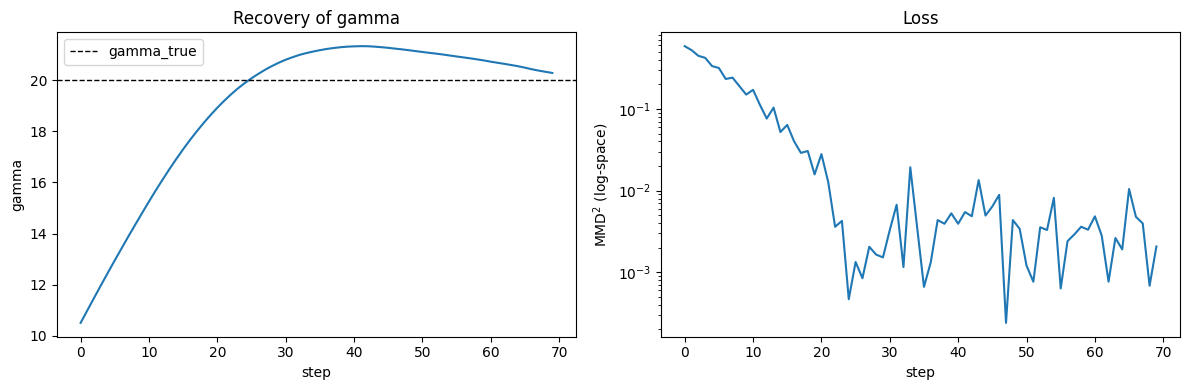

In [9]:
steps = [h[0] for h in history]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(steps, [h[1] for h in history])
ax[0].axhline(GAMMA_TRUE, color="k", ls="--", lw=1, label="gamma_true")
ax[0].set(xlabel="step", ylabel="gamma", title="Recovery of gamma")
ax[0].legend()
ax[1].plot(steps, [h[2] for h in history])
ax[1].set(xlabel="step", ylabel="MMD$^2$ (log-space)", title="Loss", yscale="log")
plt.tight_layout()
plt.show()